In [32]:
import numpy as np
import matplotlib.pyplot as plt
from games.bos import BoS
from agents.regretmatching import RegretMatching
from agents.fictitiousplay import FictitiousPlay
from agents.random_agent import RandomAgent
from agents.iql import IndependentQLearning
from agents.jal_am import JointActionLearningAM

# Battle of the Sexes (BoS)

Es un juego en donde los jugadores deben elegir entre ir al **Cine** o a un **Partido** de fútbol. Prefieren ir juntos, pero agent_0 prefiere el Cine y agent_1 el Partido.

**A diferencia de Matching Pennies y Blotto, este juego NO es de suma cero**: ambos jugadores pueden obtener utilidad positiva simultáneamente.

Matrices de utilidades `(u₀, u₁)` (filas = agent_0, columnas = agent_1):

|              | **Cine**  | **Partido** |
|--------------|:---------:|:-----------:|
| **Cine**     | (2, 1)    | (0, 0)      |
| **Partido**  | (0, 0)    | (1, 2)      |

agent_0 obtiene más utilidad coordinando en Cine; agent_1, coincidiendo en Partido. La descoordinación da 0 a ambos.

In [33]:
g = BoS()

In [34]:
g.reset()

In [35]:
g.agents

['agent_0', 'agent_1']

In [36]:
move_labels = g._moves          # ['Cine', 'Partido']
R0 = g._R['agent_0']            # matriz de agent_0
R1 = g._R['agent_1']            # matriz de agent_1
n  = g._num_actions
move_labels

['Cine', 'Partido']

## Análisis

### Estrategias dominantes

**Ningún jugador tiene estrategia dominante** (ni fuerte ni débil):


### Equilibrios de Nash

**Dos equilibrios en estrategias puras:**

(Cine, Cine)       (2,  1) <br>
(Partido, Partido) (1, 2)

**Un equilibrio en estrategia mixta:**

Para que agent_0 sea indiferente entre Cine y Partido, agent_1 debe mezclar tal que:
`u₀(Cine) = u₀(Partido)` → `q·2 = (1−q)·1` → **q = 1/3** (P(agent_1 juega Cine))

Para que agent_1 sea indiferente:
`u₁(Cine) = u₁(Partido)` → `p·1 = (1−p)·2` → **p = 2/3** (P(agent_0 juega Cine))

| Agente  | P(Cine) | P(Partido) | Utilidad esperada |
|---------|---------|------------|-------------------|
| agent_0 | 2/3     | 1/3        | **2/3 ≈ 0.667**  |
| agent_1 | 1/3     | 2/3        | **2/3 ≈ 0.667**  |

El EN mixto da a ambos jugadores una utilidad esperada de 2/3, **menor que cualquier EN puro** (que da al menos 1 al peor agente). El conflicto de coordinación hace que la solución mixta sea ineficiente. Los algoritmos de aprendizaje tienden a converger a uno de los EN puros, dependiendo de las condiciones iniciales y el oponente.

In [37]:
def play_game(game, agents, n_rounds=10000):
    """Reinicia el juego, ejecuta n_rounds rondas y retorna las políticas finales."""
    game.reset()
    for _ in range(n_rounds):
        actions = {a: agents[a].action() for a in game.agents}
        game.step(actions)
    return {a: agents[a].policy() for a in game.agents}


def track_convergence(game, agents, checkpoints):
    """Registra P(Cine) = policy()[0] en cada checkpoint. Retorna dict de historiales."""
    game.reset()
    history = {a: [] for a in game.agents}
    step = 0
    for cp in checkpoints:
        for _ in range(cp - step):
            actions = {a: agents[a].action() for a in game.agents}
            game.step(actions)
        step = cp
        for a in game.agents:
            history[a].append(agents[a].policy()[0])
    return history


def plot_convergence(history, checkpoints, title):
    """Grafica P(Cine) de cada agente con los tres equilibrios de Nash como referencia."""
    fig, ax = plt.subplots(figsize=(9, 5))
    for agent, values in history.items():
        ax.plot(checkpoints, values, marker='o', label=agent)
    ax.axhline(1.0, color='green',  linestyle='--', alpha=0.6, label='EN puro: (Cine, Cine) — P(Cine)=1')
    ax.axhline(0.0, color='red',    linestyle='--', alpha=0.6, label='EN puro: (Partido, Partido) — P(Cine)=0')
    ax.axhline(2/3, color='blue',   linestyle=':',  alpha=0.7, label='EN mixto agent_0: P(Cine)=2/3')
    ax.axhline(1/3, color='orange', linestyle=':',  alpha=0.7, label='EN mixto agent_1: P(Cine)=1/3')
    ax.set_xscale('log')
    ax.set_xlabel('Rondas (escala log)')
    ax.set_ylabel('P(jugar Cine)')
    ax.set_title(title)
    ax.legend(loc='center right', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
    plt.tight_layout()
    plt.show()

## Experimentos: política final aprendida

Para cada experimento se muestra la política final aprendida y la acción preferida (argmax). Dada la estructura del juego, esperamos convergencia a uno de los dos equilibrios de Nash puros.

### Regret Matching vs Regret Matching

In [38]:
agents = {a: RegretMatching(game=g, agent=a) for a in g.agents}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'Cine': np.float64(0.0), 'Partido': np.float64(1.0)},
 'agent_1': {'Cine': np.float64(0.0), 'Partido': np.float64(1.0)}}

In [39]:
# Acción preferida (argmax)
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': 'Partido', 'agent_1': 'Partido'}

### Regret Matching vs Random Agent

In [40]:
agents = {'agent_0': RegretMatching(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'Cine': np.float64(0.998), 'Partido': np.float64(0.002)},
 'agent_1': {'Cine': np.float64(0.5), 'Partido': np.float64(0.5)}}

In [41]:
# Acción preferida (argmax)
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': 'Cine', 'agent_1': 'Cine'}

### Fictitious Play vs Fictitious Play

In [42]:
agents = {a: FictitiousPlay(game=g, agent=a) for a in g.agents}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'Cine': np.float64(0.0), 'Partido': np.float64(1.0)},
 'agent_1': {'Cine': np.float64(0.0), 'Partido': np.float64(1.0)}}

In [43]:
# Acción preferida (argmax)
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': 'Partido', 'agent_1': 'Partido'}

### Fictitious Play vs Random Agent

In [44]:
agents = {'agent_0': FictitiousPlay(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'Cine': np.float64(0.999), 'Partido': np.float64(0.001)},
 'agent_1': {'Cine': np.float64(0.5), 'Partido': np.float64(0.5)}}

In [45]:
# Acción preferida (argmax)
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': 'Cine', 'agent_1': 'Cine'}

### IQL vs Random Agent

In [46]:
agents = {'agent_0': IndependentQLearning(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'Cine': np.float64(0.931), 'Partido': np.float64(0.069)},
 'agent_1': {'Cine': np.float64(0.5), 'Partido': np.float64(0.5)}}

In [47]:
# Acción preferida (argmax)
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': 'Cine', 'agent_1': 'Cine'}

### IQL vs IQL

In [48]:
agents = {a: IndependentQLearning(game=g, agent=a) for a in g.agents}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'Cine': np.float64(1.0), 'Partido': np.float64(0.0)},
 'agent_1': {'Cine': np.float64(0.935), 'Partido': np.float64(0.065)}}

In [49]:
# Acción preferida (argmax)
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': 'Cine', 'agent_1': 'Cine'}

### IQL vs Joint Action Learning AM

In [50]:
agents = {'agent_0': IndependentQLearning(game=g, agent='agent_0'), 'agent_1': JointActionLearningAM(game=g, agent='agent_1')}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'Cine': np.float64(0.088), 'Partido': np.float64(0.912)},
 'agent_1': {'Cine': np.float64(0.0), 'Partido': np.float64(1.0)}}

In [51]:
# Acción preferida (argmax)
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': 'Partido', 'agent_1': 'Partido'}

### Joint Action Learning AM vs Joint Action Learning AM

In [52]:
agents = {a: JointActionLearningAM(game=g, agent=a) for a in g.agents}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'Cine': np.float64(0.272), 'Partido': np.float64(0.728)},
 'agent_1': {'Cine': np.float64(0.0), 'Partido': np.float64(1.0)}}

In [53]:
# Acción preferida (argmax)
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': 'Partido', 'agent_1': 'Partido'}

## Análisis de Convergencia

Se registra **P(Cine)** de cada agente a lo largo del tiempo.

Referencias en los gráficos:
- Verde discontinua: EN puro (Cine, Cine) → P(Cine) = 1
- Roja discontinua: EN puro (Partido, Partido) → P(Cine) = 0
- Azul punteada: EN mixto para agent_0 → P(Cine) = 2/3
- Naranja punteada: EN mixto para agent_1 → P(Cine) = 1/3

In [54]:
checkpoints = [10, 50, 100, 500, 1000, 5000, 10000]

### Regret Matching vs Regret Matching

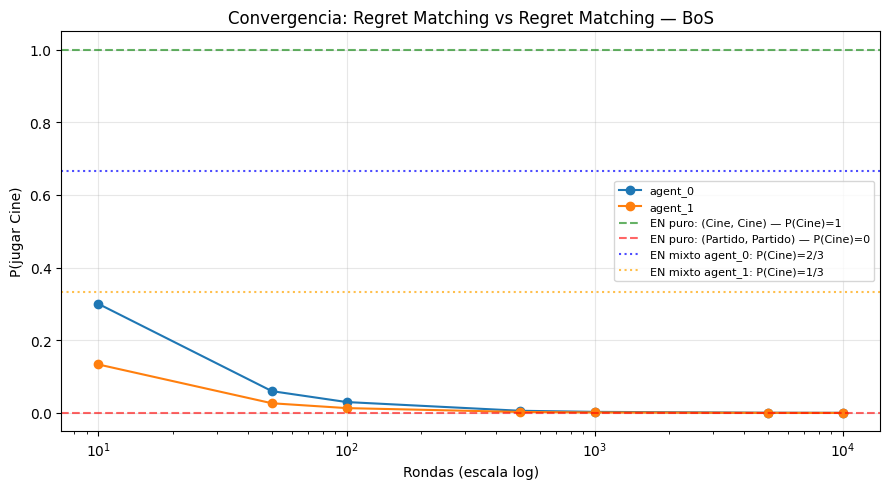

In [55]:
agents = {a: RegretMatching(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: Regret Matching vs Regret Matching — BoS')

### Regret Matching vs Random Agent

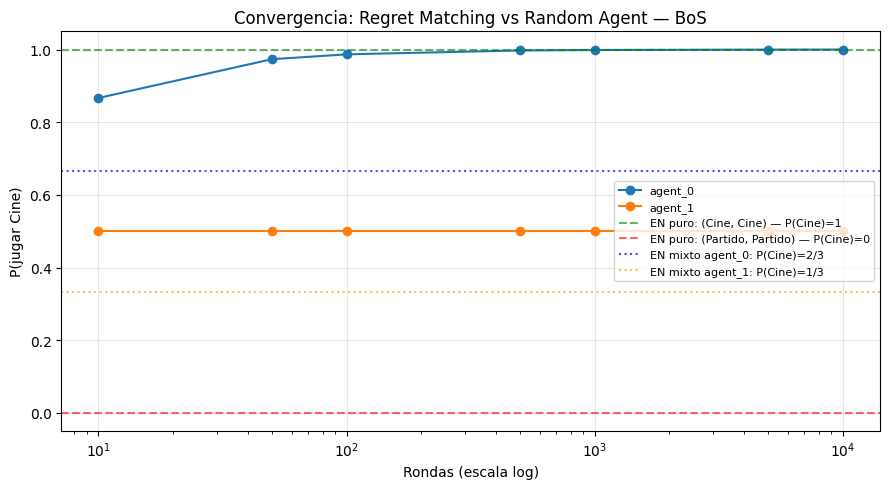

In [56]:
agents = {'agent_0': RegretMatching(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: Regret Matching vs Random Agent — BoS')

### Fictitious Play vs Fictitious Play

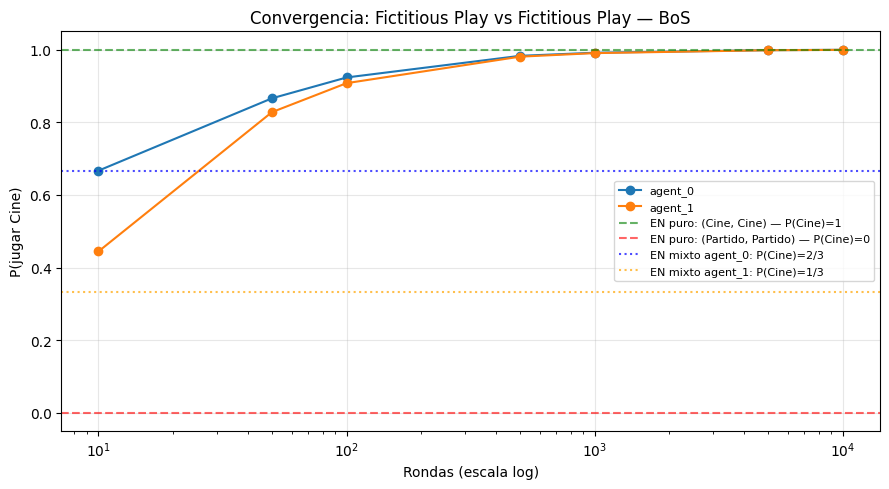

In [57]:
agents = {a: FictitiousPlay(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: Fictitious Play vs Fictitious Play — BoS')

### Fictitious Play vs Random Agent

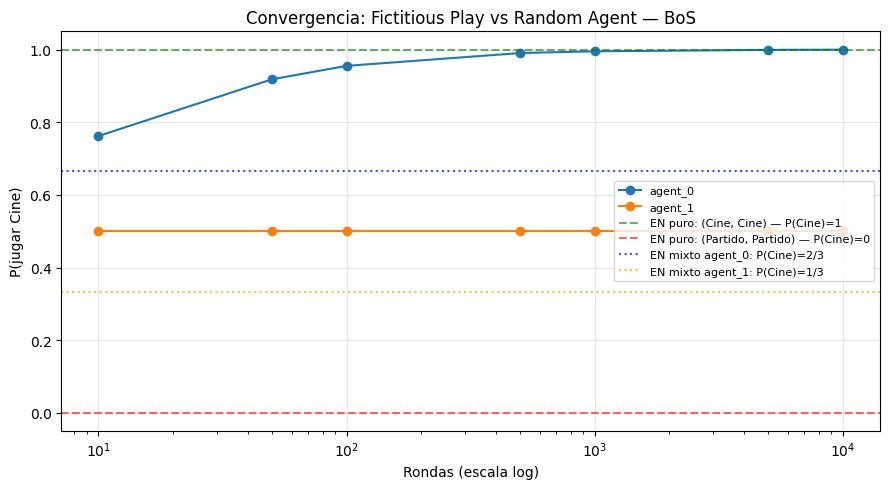

In [58]:
agents = {'agent_0': FictitiousPlay(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: Fictitious Play vs Random Agent — BoS')

### IQL vs Random Agent

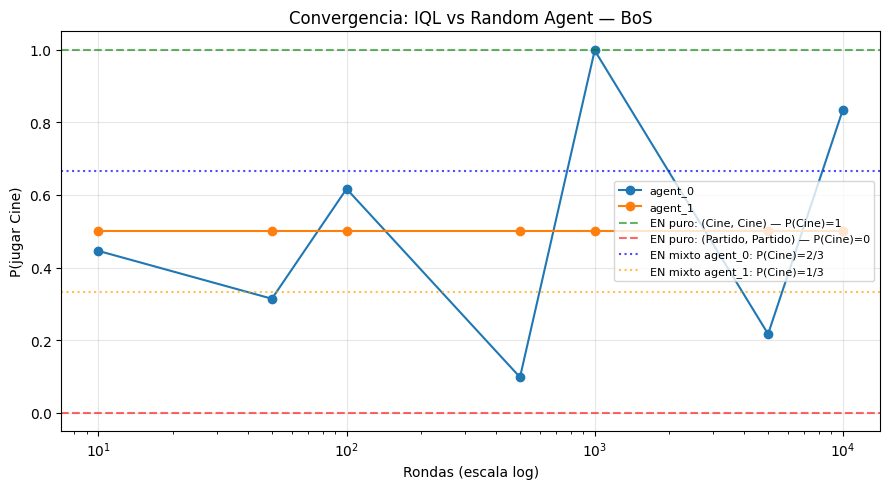

In [59]:
agents = {'agent_0': IndependentQLearning(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: IQL vs Random Agent — BoS')

### IQL vs IQL

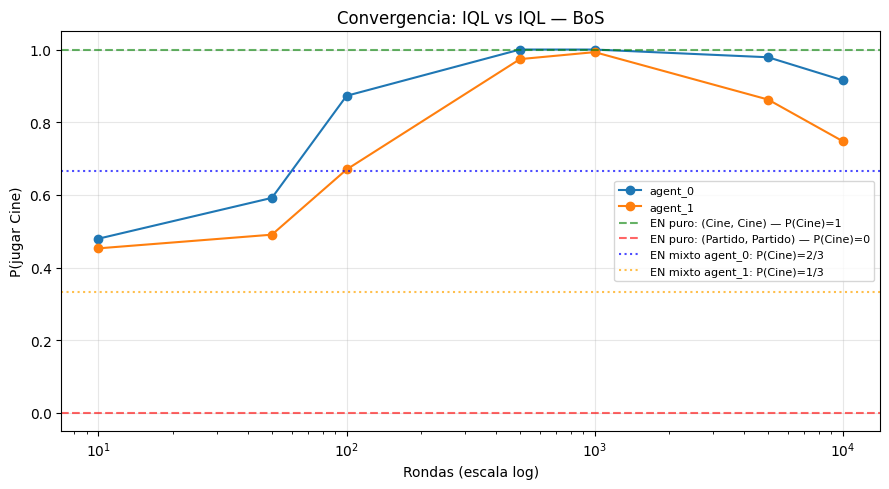

In [60]:
agents = {a: IndependentQLearning(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: IQL vs IQL — BoS')

### IQL vs Joint Action Learning AM

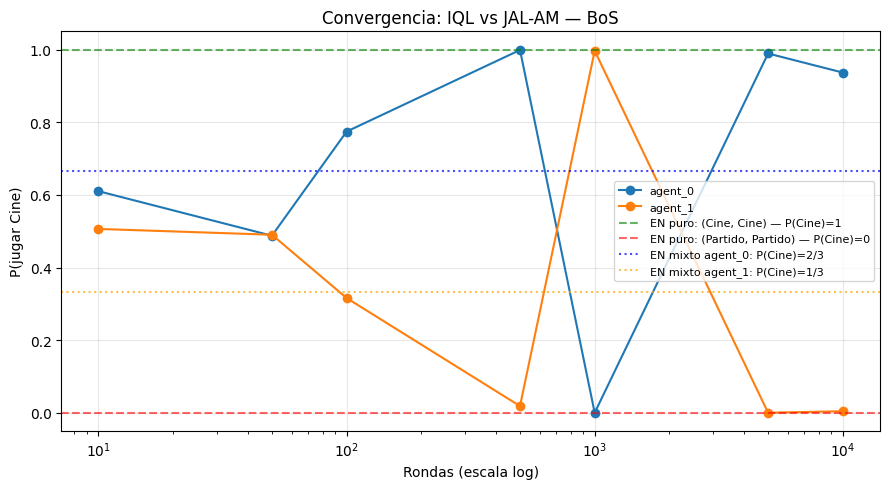

In [61]:
agents = {'agent_0': IndependentQLearning(game=g, agent='agent_0'), 'agent_1': JointActionLearningAM(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: IQL vs JAL-AM — BoS')

### Joint Action Learning AM vs Joint Action Learning AM

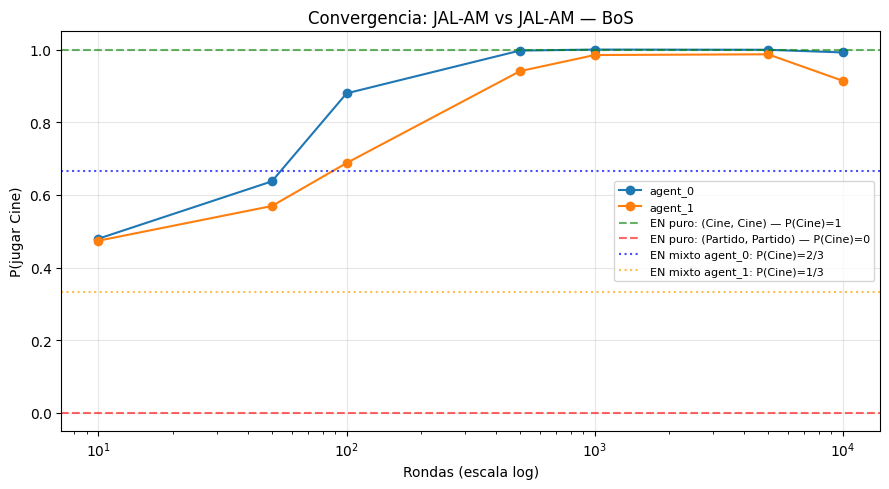

In [62]:
agents = {a: JointActionLearningAM(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: JAL-AM vs JAL-AM — BoS')

## Conclusiones
- Generalmente los agentes tienden a buscar los equilibrios, salvo el agente Random y el caso particular en donde IQL juega vs JAL-AM.
- No se han encontrado casos en los que los agentes converjan a equilibrios correlacionados, siempre se tiende a converger hacia los puros.
- Fictitious y Matching son los agentes que convergen más rápido, mientras que JAL-AM lo hace un poco más lento, e IQL se muestra como el más inestable, aunque en algunos casos logra converger a equilibrios puros.